# Stock Data Exploration

This notebook performs exploratory data analysis (EDA) on monthly market and macroeconomic indicators.

Dataset: `data/combined_monthly.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_PATH = "data/combined_monthly.csv"
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,SP500,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate
0,2011-01-01,1286.119995,92.190002,3.378,4.4510,220.4,221.187,9.1
1,2011-02-01,1327.219971,96.970001,3.414,4.4780,239.8,221.898,9.0
2,2011-03-01,1325.829956,106.720001,3.454,4.3000,248.1,223.046,9.0
3,2011-04-01,1363.609985,113.930000,3.296,4.1655,257.3,224.093,9.1
4,2011-06-01,1320.640015,95.419998,3.158,4.2720,250.3,224.806,9.1


## 1. Data Snapshot

In [ ]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

df.describe(include="all").transpose()

Rows: 138, Columns: 8

Column types:
Date                 datetime64[ns]
SP500                       float64
Crude_Oil                   float64
US_10Y_Yield                float64
Copper                      float64
Steel_PPI                   float64
CPI                         float64
Unemployment_Rate           float64
dtype: object

Date range:
2011-01-01 00:00:00 to 2024-05-01 00:00:00


,count,mean,min,25%,50%,75%,max,std
Date,138,2017-09-29 17:54:46.956521728,2011-01-01 00:00:00,2014-05-16 06:00:00,2017-10-01 12:00:00,2021-02-22 00:00:00,2024-05-01 00:00:00,NaN
SP500,138.0,2754.267827,1131.420044,1920.915009,2513.105103,3778.052429,5277.509766,1128.750154
Crude_Oil,138.0,71.329275,18.84,51.802499,72.450001,91.932501,113.93,21.759977
US_10Y_Yield,138.0,2.362986,0.536,1.7415,2.2755,2.791,4.686,0.90084
Copper,138.0,3.279967,2.064,2.704375,3.18575,3.797375,4.743,0.694646
Steel_PPI,138.0,284.850775,170.3,217.925,229.1,315.6815,711.611,123.75081
CPI,138.0,254.776457,221.187,236.2295,246.8595,264.6155,313.175,25.809228
Unemployment_Rate,138.0,5.606522,3.4,3.8,4.9,7.125,14.8,2.138633


## 2. Data Quality Checks

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

display(missing.to_frame("missing_values"))
print(f"Duplicate rows: {duplicates}")

,missing_values
Date,0
SP500,0
Crude_Oil,0
US_10Y_Yield,0
Copper,0
Steel_PPI,0
CPI,0
Unemployment_Rate,0


Duplicate rows: 0


## 3. Time-Series Trends

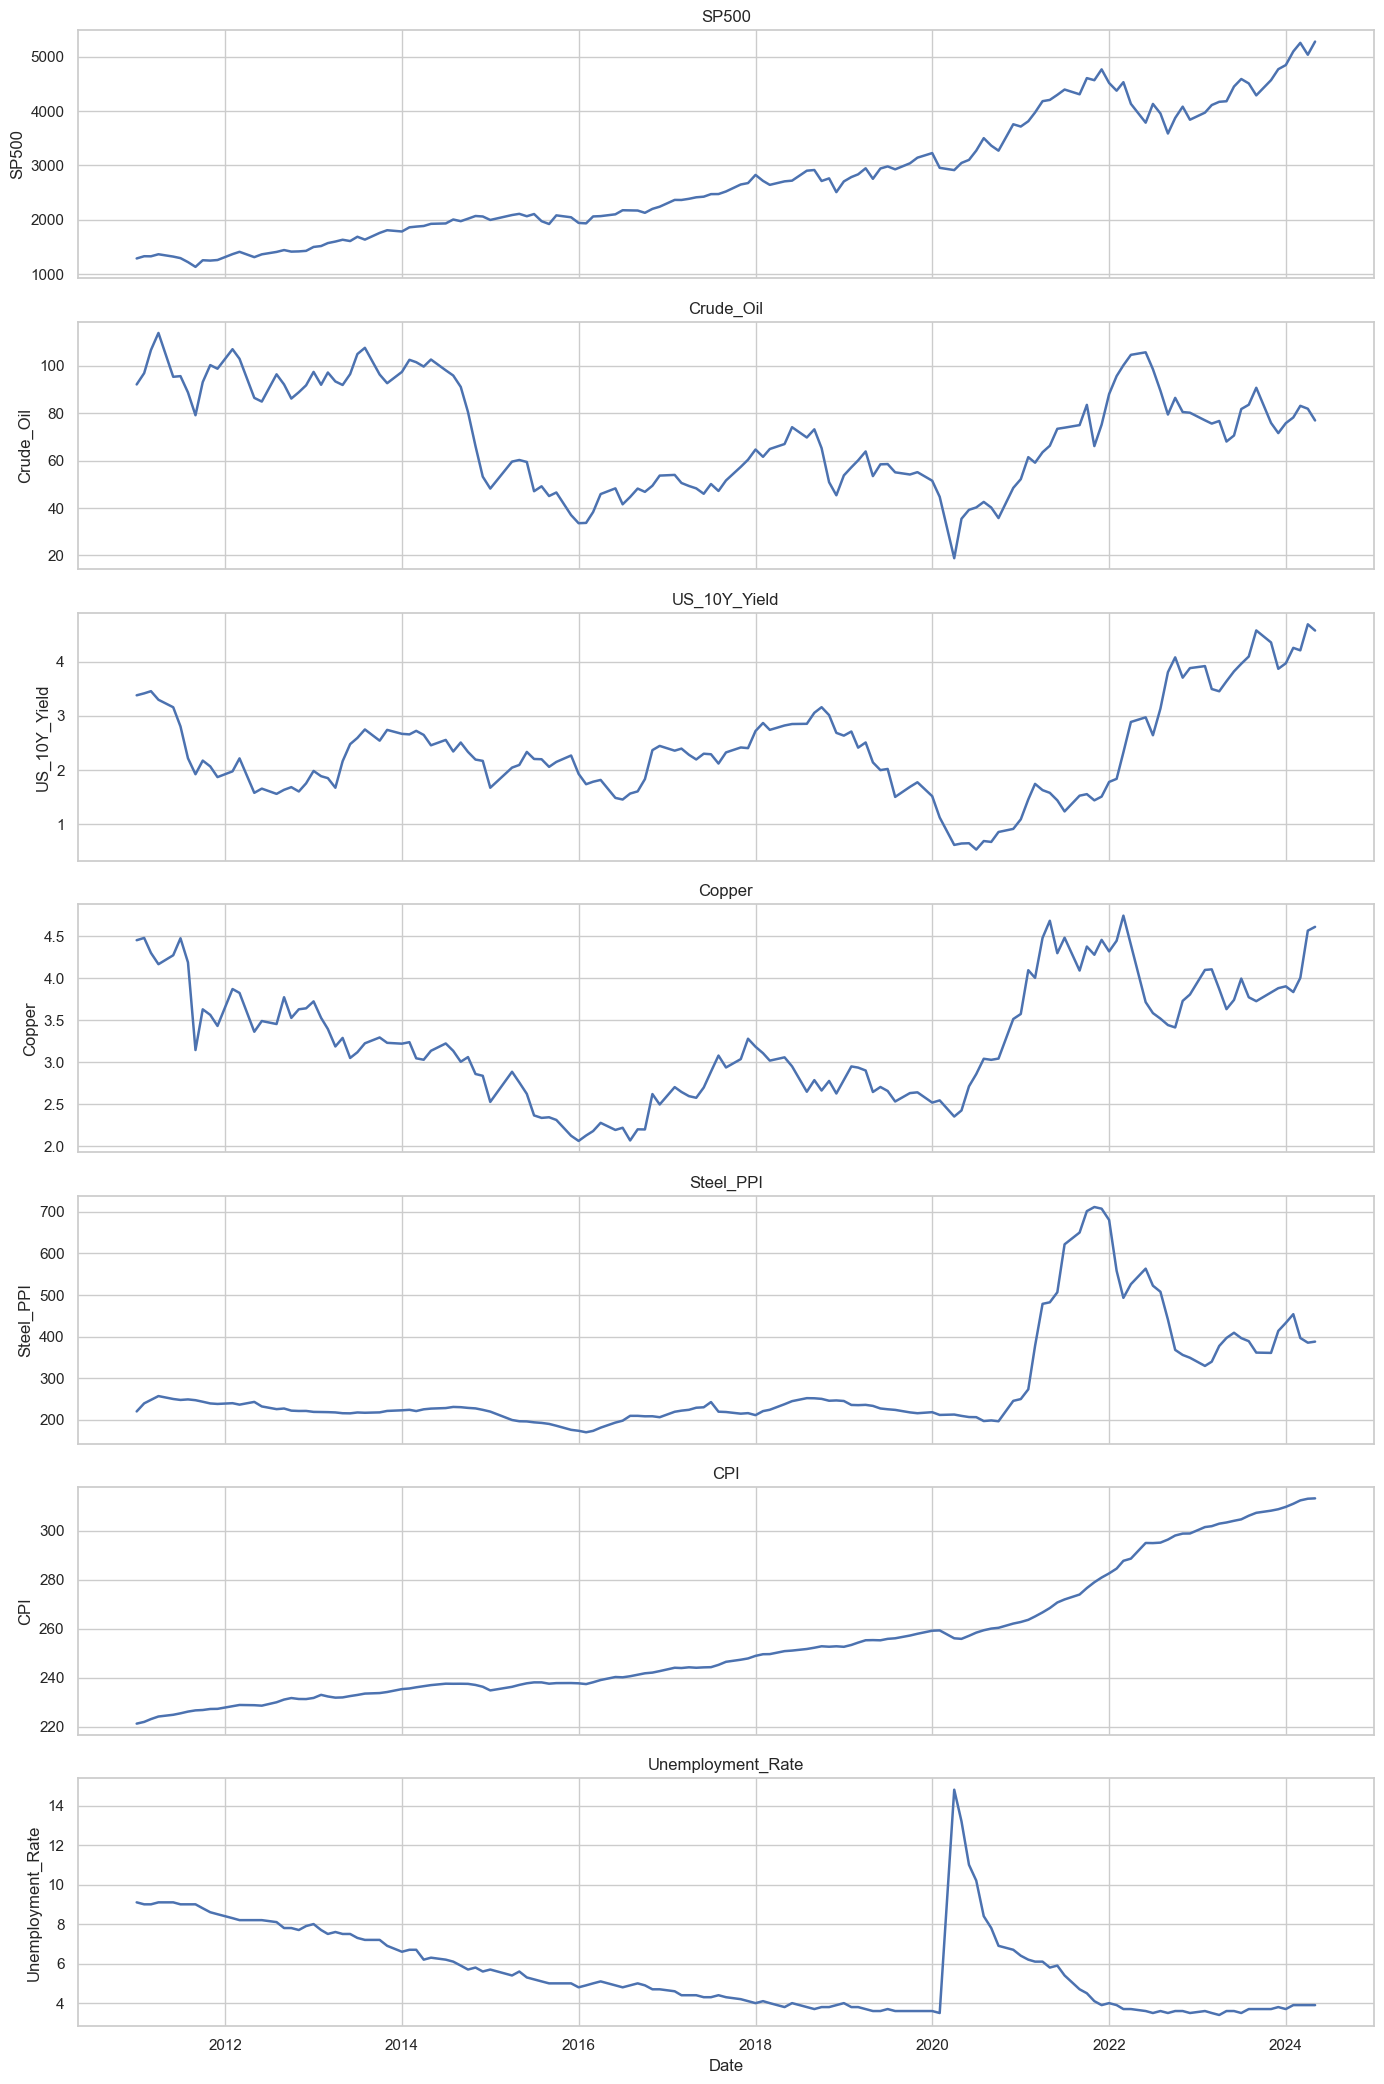

In [ ]:
numeric_cols = [c for c in df.columns if c != "Date"]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 3 * len(numeric_cols)), sharex=True)

for ax, col in zip(axes, numeric_cols):
    ax.plot(df["Date"], df[col], linewidth=1.8)
    ax.set_title(col)
    ax.set_ylabel(col)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

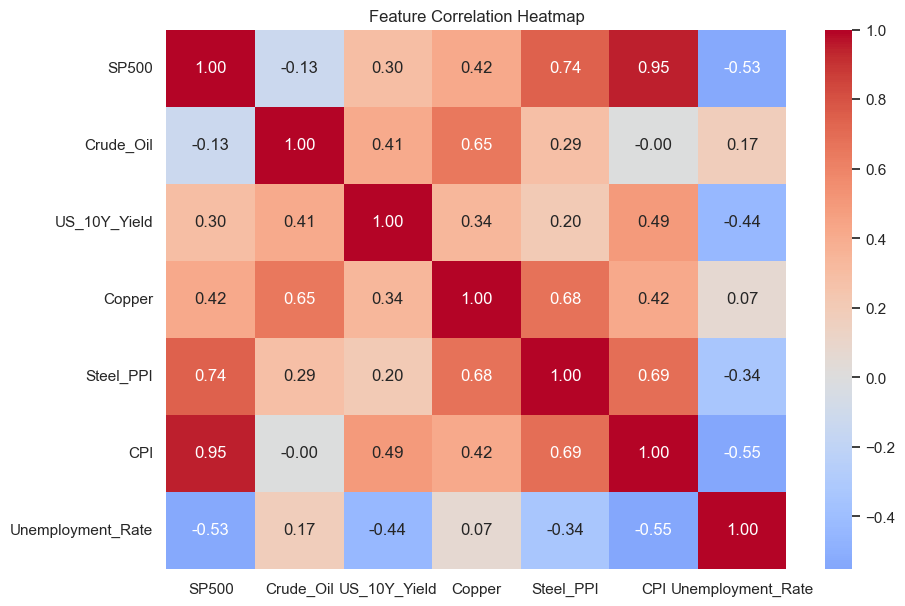

In [ ]:
corr = df.drop(columns=["Date"]).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. SP500 Return Behavior

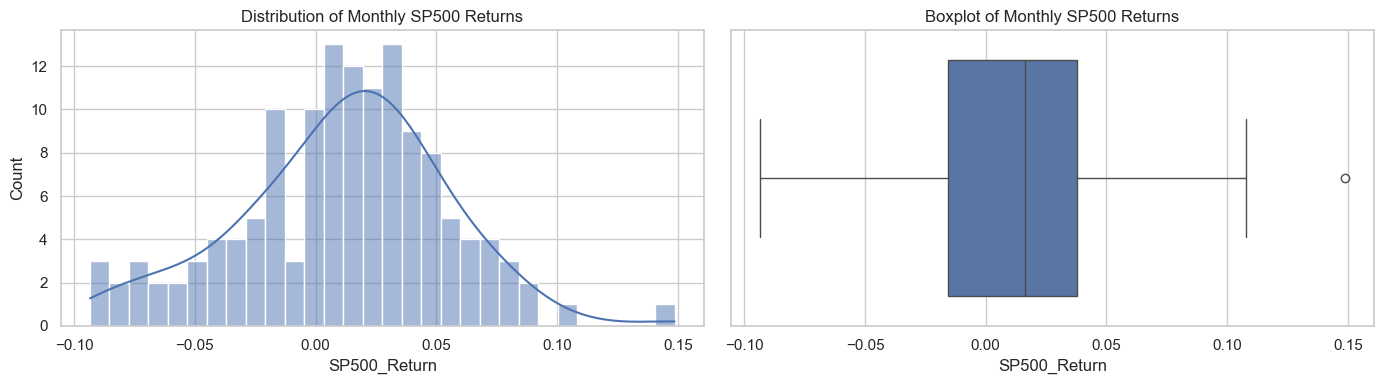

In [ ]:
df["SP500_Return"] = df["SP500"].pct_change()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["SP500_Return"].dropna(), bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribution of Monthly SP500 Returns")

sns.boxplot(x=df["SP500_Return"].dropna(), ax=ax[1])
ax[1].set_title("Boxplot of Monthly SP500 Returns")

plt.tight_layout()
plt.show()

## 6. Rolling Trend and Pairwise View

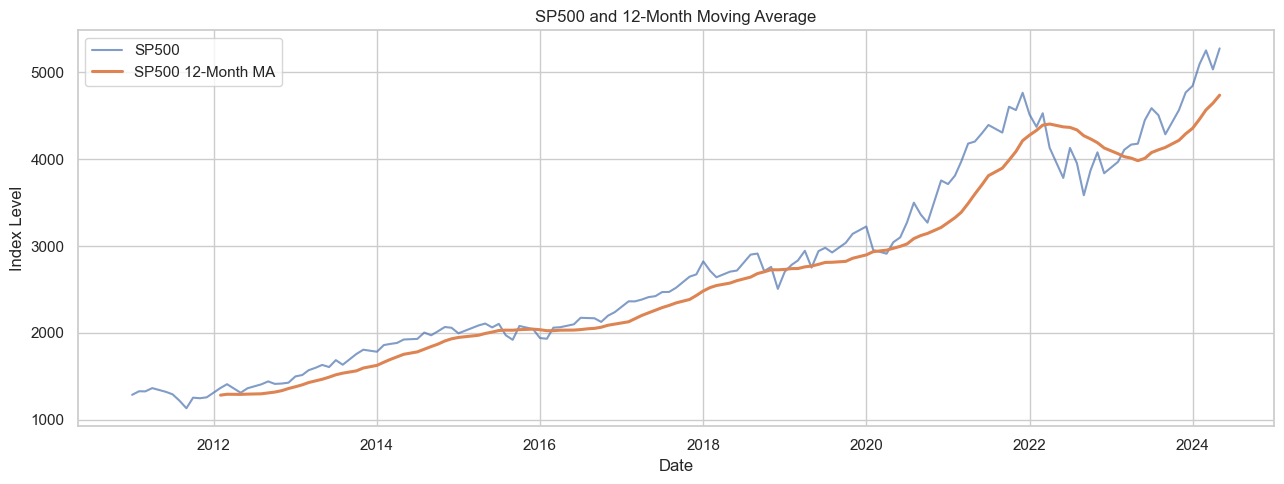

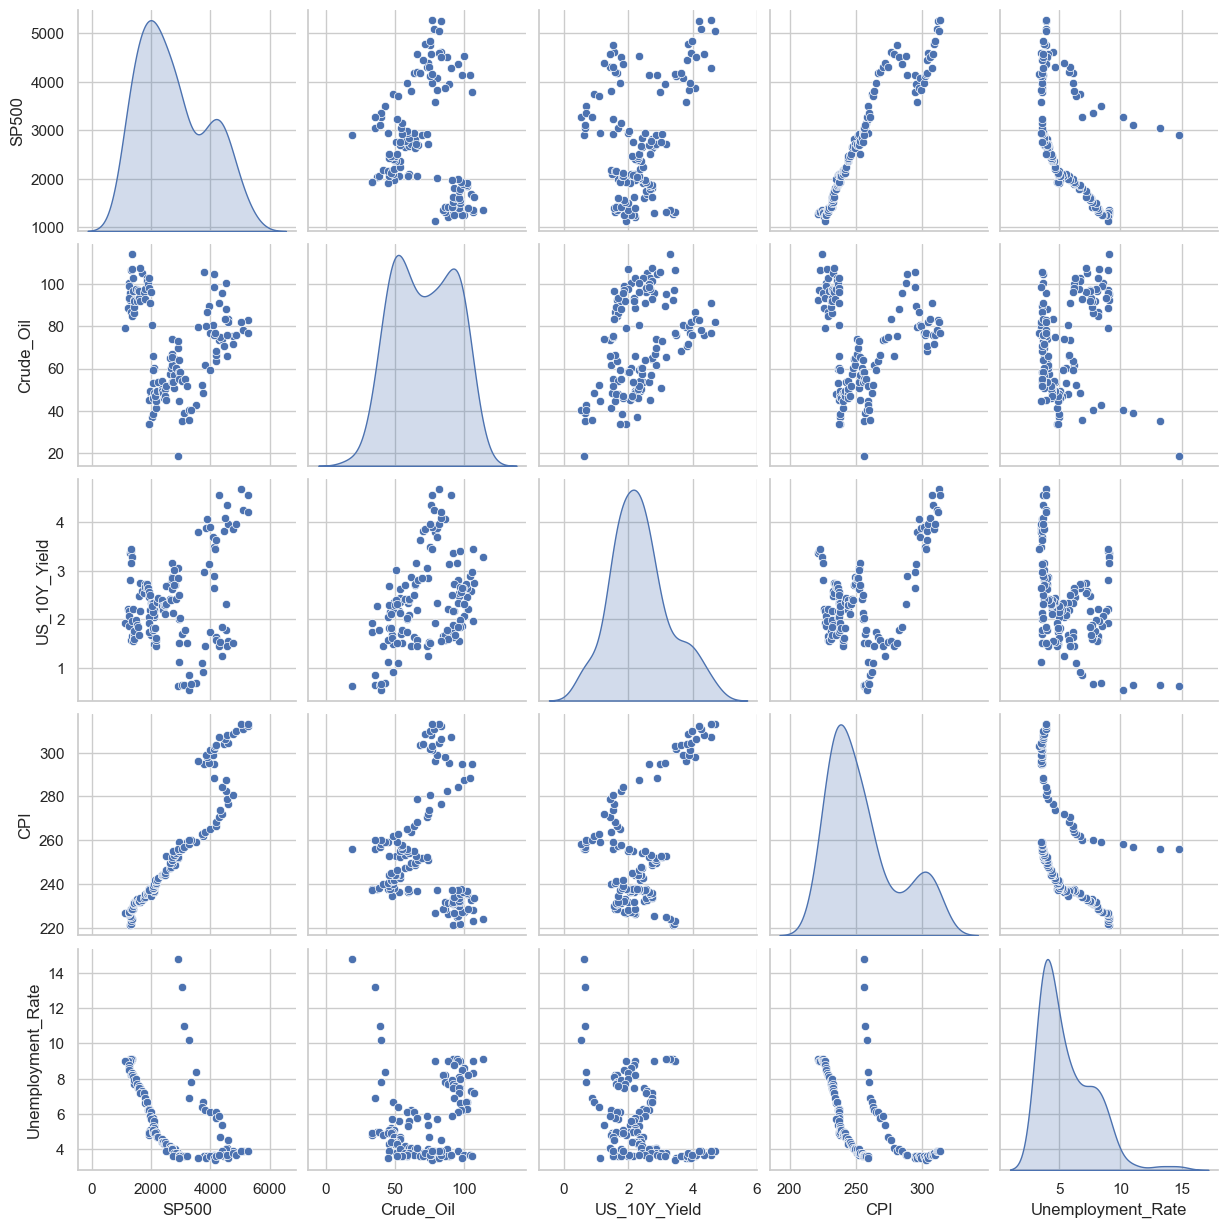

In [ ]:
df["SP500_12M_MA"] = df["SP500"].rolling(window=12).mean()

plt.figure(figsize=(13, 5))
plt.plot(df["Date"], df["SP500"], label="SP500", alpha=0.7)
plt.plot(df["Date"], df["SP500_12M_MA"], label="SP500 12-Month MA", linewidth=2.2)
plt.title("SP500 and 12-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.tight_layout()
plt.show()

sns.pairplot(df[["SP500", "Crude_Oil", "US_10Y_Yield", "CPI", "Unemployment_Rate"]].dropna(), diag_kind="kde")
plt.show()

## 7. Create Running-Average Dataset (2020 Smoothing)

In [ ]:
base_cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
df_running_avg_20 = df[base_cols].copy()

numeric_cols = [c for c in base_cols if c != "Date"]
mask_2020 = df_running_avg_20["Date"].dt.year == 2020

# Replace 2020 values with a cumulative monthly running average within 2020.
df_running_avg_20.loc[mask_2020, numeric_cols] = (
    df_running_avg_20.loc[mask_2020, numeric_cols]
    .expanding(min_periods=1)
    .mean()
    .to_numpy()
)

output_path = "data/combined_monthly_running_avg_20.csv"
df_running_avg_20.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print("Output columns:", df_running_avg_20.columns.tolist())
display(df_running_avg_20.loc[mask_2020, ["Date"] + numeric_cols])

Saved to data/combined_monthly_running_avg_20_1.csv
Output columns: ['Date', 'SP500', 'Crude_Oil', 'US_10Y_Yield', 'Copper', 'Steel_PPI', 'CPI', 'Unemployment_Rate']


,Date,SP500,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate
91,2020-01-01,3225.520020,51.560001,1.520000,2.520000,218.600000,259.127000,3.600000
92,2020-02-01,3089.869995,48.160000,1.323500,2.533000,215.300000,259.188500,3.550000
93,2020-04-01,3030.723307,38.386667,1.089667,2.473333,214.500000,258.136333,7.300000
94,2020-05-01,3034.119995,37.662500,0.979250,2.461625,213.300000,257.552750,8.775000
95,2020-06-01,3047.354004,37.984000,0.914000,2.512000,212.020000,257.450600,9.220000
96,2020-07-01,3084.648356,38.365000,0.851000,2.569833,211.116667,257.600833,9.383333
97,2020-08-01,3144.028599,38.971429,0.828429,2.637143,209.142857,257.845857,9.242857
98,2020-09-01,3171.400024,39.127501,0.809500,2.686063,207.850000,258.114750,9.062500
99,2020-10-01,3182.351128,38.756667,0.815111,2.725778,206.622222,258.359667,8.822222
100,2020-12-01,3239.723022,39.733001,0.825300,2.804600,210.540000,258.728200,8.610000


## 8. Compare Original vs Running-Average Dataset

In [ ]:
orig_path = "data/combined_monthly.csv"
smoothed_path = "data/combined_monthly_running_avg_20.csv"

orig_df = pd.read_csv(orig_path, parse_dates=["Date"]).sort_values("Date")
smoothed_df = pd.read_csv(smoothed_path, parse_dates=["Date"]).sort_values("Date")

compare_cols = [c for c in orig_df.columns if c != "Date"]

fig, axes = plt.subplots(len(compare_cols), 1, figsize=(14, 3 * len(compare_cols)), sharex=True)

for ax, col in zip(axes, compare_cols):
    ax.plot(orig_df["Date"], orig_df[col], label="Original", alpha=0.85)
    ax.plot(smoothed_df["Date"], smoothed_df[col], label="Running Avg (2020)", linewidth=2)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.legend(loc="best")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 9. Next Steps

Use this EDA to decide:
- Which features are strongly associated with `SP500`.
- Whether lag features (for example, 1, 3, 6 month lags) may help prediction.
- Whether stationarity transformations (returns/differences) are needed for modeling.